In [4]:
import sys
import gtsam
import gtsam.utils.plot as gtsam_plot
import matplotlib.pyplot as plt
from gtsam.symbol_shorthand import X
import numpy as np

from typing import Optional
from functools import partial

In [27]:
p1 = gtsam.Pose2((1,1,np.pi/4))
p1.__getstate__()

('22 serialization::archive 20 1 0\n0 0 0 5.27393087579049347e-01 1.27323954473516254e+00 1 0\n1 7.07106781186547573e-01 7.07106781186547462e-01\n',)

In [28]:
# help(gtsam.Marginals)
gtsam.__dir__()

['__name__',
 '__doc__',
 '__package__',
 '__loader__',
 '__spec__',
 '__path__',
 '__file__',
 '__cached__',
 '__builtins__',
 'sys',
 'utils',
 'findExampleDataFile',
 'gtsam',
 'MT19937',
 'IndexPair',
 'DSFMapIndexPair',
 'Value',
 'GenericValueVector',
 'GenericValueMatrix',
 'GenericValuePoint2',
 'GenericValuePoint3',
 'GenericValueRot2',
 'GenericValueRot3',
 'GenericValuePose2',
 'GenericValuePose3',
 'GenericValueStereoPoint2',
 'GenericValueCal3_S2',
 'GenericValueCal3DS2',
 'GenericValueCal3Bundler',
 'GenericValueCal3Fisheye',
 'GenericValueCal3Unified',
 'GenericValueEssentialMatrix',
 'GenericValueCalibratedCamera',
 'GenericValueConstantBias',
 'isDebugVersion',
 'IndexPairSetAsArray',
 'linear_independent',
 'Symbol',
 'symbol_shorthand',
 'LabeledSymbol',
 'EdgeKey',
 'Ordering',
 'DotWriter',
 'VariableIndex',
 'Factor',
 'PrintKeyList',
 'PrintKeyVector',
 'PrintKeySet',
 'symbol',
 'symbolChr',
 'symbolIndex',
 'mrsymbol',
 'mrsymbolChr',
 'mrsymbolLabel',
 'mrsymb

In [29]:
print("Python executable:", sys.executable)
print("GTSAM module file:", gtsam.__file__)

Python executable: /Users/ovar/miniforge3/envs/gtsam_dbg/bin/python
GTSAM module file: /Users/ovar/miniforge3/envs/gtsam_dbg/lib/python3.10/site-packages/gtsam/__init__.py


## 2 Modeling Robot Motion
### 2.2 Creating a Factor Graph

In [30]:
# Create an empty nonlinear factor graph
graph = gtsam.NonlinearFactorGraph()

# Add a Gaussian prior on pose x_1
priorMean = gtsam.Pose2(0.0, 0.0, 0.0)
priorNoise = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.3, 0.3, 0.1])) 
graph.add(gtsam.PriorFactorPose2(1, priorMean, priorNoise))

# Add two odemetry factors
odometry = gtsam.Pose2(2.0, 0.0, 0.0)
odometryNoise = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.2, 0.2, 0.1]))
graph.add(gtsam.BetweenFactorPose2(1, 2, odometry, odometryNoise))
graph.add(gtsam.BetweenFactorPose2(2, 3, odometry, odometryNoise))

graph.print("Factor Graph:\n")

Factor Graph:
size: 3

Factor 0: PriorFactor on 1
  prior mean:  (0, 0, 0)
  noise model: diagonal sigmas [0.3; 0.3; 0.1];

Factor 1: BetweenFactor(1,2)
  measured:  (2, 0, 0)
  noise model: diagonal sigmas [0.2; 0.2; 0.1];

Factor 2: BetweenFactor(2,3)
  measured:  (2, 0, 0)
  noise model: diagonal sigmas [0.2; 0.2; 0.1];



### 2.4 Non-linear Optimization in GTSAM

In [31]:
1 # create (deliberatly inaccurate) initial estimate
initial = gtsam.Values()
initial.insert(1, gtsam.Pose2(0.5, 0.0, 0.2))
initial.insert(2, gtsam.Pose2(2.3, 0.1, -0.2))
initial.insert(3, gtsam.Pose2(4.1, 0.1, 0.1))

result = gtsam.LevenbergMarquardtOptimizer(graph, initial).optimize()
result.print("Result:\n")

Result:

Values with 3 values:
Value 1: (gtsam::Pose2)
(7.46978315e-16, -5.34409096e-16, -1.78381863e-16)

Value 2: (gtsam::Pose2)
(2, -1.09236636e-15, -2.48671179e-16)

Value 3: (gtsam::Pose2)
(4, -1.70076056e-15, -2.50943863e-16)



In [79]:
gaussian_fg = graph.linearize(result)
bayes_tree, factor_graph = gaussian_fg.eliminatePartialMultifrontal([1])

# bayes_tree.print("Bayes Tree:\n")
# factor_graph.print("Factor Graph:\n")
marg = factor_graph.eliminateMultifrontal()
fg = gtsam.GaussianFactorGraph(marg)
info = fg.augmentedHessian()[:-1,:-1]
cov = np.linalg.inv(info)
print(np.array2string(cov, formatter={"float_kind": lambda x: f"{x:.2f}"}))

[[0.13 0.00 0.00 0.13 0.00 0.00]
 [0.00 0.17 0.02 0.00 0.21 0.02]
 [0.00 0.02 0.02 0.00 0.06 0.02]
 [0.13 0.00 0.00 0.17 0.00 0.00]
 [0.00 0.21 0.06 0.00 0.37 0.06]
 [0.00 0.02 0.02 0.00 0.06 0.03]]


#### Full Posterio Inference

In [4]:
marginals = gtsam.Marginals(graph, result)
np.set_printoptions(precision=3, suppress=True)
# marginals.print("Marginals:\n")
print("x1 covariance:\n" + str(marginals.marginalCovariance(1)))
print("x2 covariance:\n" + str(marginals.marginalCovariance(2)))
print("x3 covariance:\n" + str(marginals.marginalCovariance(3)))

x1 covariance:
[[0.09 0.   0.  ]
 [0.   0.09 0.  ]
 [0.   0.   0.01]]
x2 covariance:
[[0.13 0.   0.  ]
 [0.   0.17 0.02]
 [0.   0.02 0.02]]
x3 covariance:
[[0.17 0.   0.  ]
 [0.   0.37 0.06]
 [0.   0.06 0.03]]


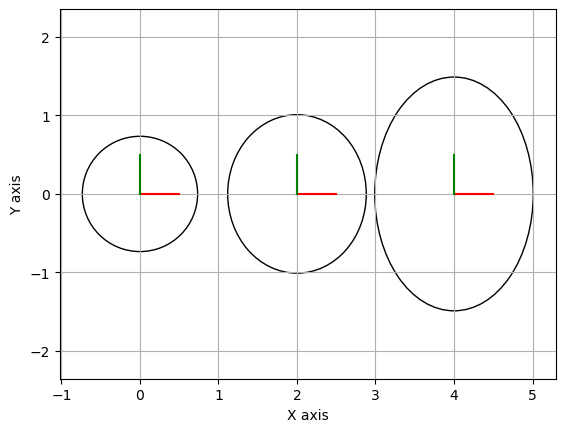

In [5]:
gtsam_plot.plot_pose2(0, result.atPose2(1), 0.5, marginals.marginalCovariance(1))
gtsam_plot.plot_pose2(0, result.atPose2(2), 0.5, marginals.marginalCovariance(2))
gtsam_plot.plot_pose2(0, result.atPose2(3), 0.5, marginals.marginalCovariance(3))
plt.axis('equal')
plt.grid('on')
plt.show()

## 3 Robot Localization
### 3.3 Using Custom Factors

https://gitlab.sintef.no/nix-flakes/gtsam/-/blob/master/python/CustomFactors.md 
https://github.com/borglab/gtsam/blob/develop/gtsam/nonlinear/doc/CustomFactor.ipynb 
https://github.com/borglab/gtsam/blob/develop/python/gtsam/examples/CustomFactorExample.py 

In [6]:
def error_gps(measurement: np.ndarray,
              this: gtsam.CustomFactor,
              values: gtsam.Values, 
              H: Optional[list[np.ndarray]]) -> np.ndarray:
    """GPS Factor error function
    :param measurement: GPS measurement, to be filled with `partial`
    :param this: gtsam.CustomFactor handle
    :param values: gtsam.Values
    :param H: Optional list of Jacobians
    :return: the unwhitened error
    """
    
    key = this.keys()[0]
    estimate_pose = values.atPose2(key)
    estimate_position = np.array([estimate_pose.x(), estimate_pose.y()])
    error = estimate_position - measurement

    if H is not None:
        H[0] = np.array([[1, 0, 0], [0, 1, 0]])

    return error

In [7]:
unaryNoise = gtsam.noiseModel.Diagonal.Sigmas([0.1, 0.1])
graph.add(gtsam.CustomFactor(unaryNoise, [1], partial(error_gps, np.array([0.0, 0.0]))))
graph.add(gtsam.CustomFactor(unaryNoise, [2], partial(error_gps, np.array([2.0, 0.0]))))
graph.add(gtsam.CustomFactor(unaryNoise, [3], partial(error_gps, np.array([4.0, 0.0]))))
graph.print()

NonlinearFactorGraph: size: 6

Factor 0: PriorFactor on 1
  prior mean:  (0, 0, 0)
  noise model: diagonal sigmas [0.3; 0.3; 0.1];

Factor 1: BetweenFactor(1,2)
  measured:  (2, 0, 0)
  noise model: diagonal sigmas [0.2; 0.2; 0.1];

Factor 2: BetweenFactor(2,3)
  measured:  (2, 0, 0)
  noise model: diagonal sigmas [0.2; 0.2; 0.1];

Factor 3: CustomFactor on 1
isotropic dim=2 sigma=0.1

Factor 4: CustomFactor on 2
isotropic dim=2 sigma=0.1

Factor 5: CustomFactor on 3
isotropic dim=2 sigma=0.1



In [8]:
result = gtsam.LevenbergMarquardtOptimizer(graph, initial).optimize()
result.print("Result:\n")

Result:

Values with 3 values:
Value 1: (gtsam::Pose2)
(-9.27935405e-17, 3.49728654e-18, 4.98922465e-19)

Value 2: (gtsam::Pose2)
(2, 3.67247512e-19, 5.49918357e-19)

Value 3: (gtsam::Pose2)
(4, -3.92959853e-19, 6.75866117e-19)



In [9]:
marginals = gtsam.Marginals(graph, result)
np.set_printoptions(precision=4, suppress=True)
# marginals.print("Marginals:\n")
print("x1 covariance:\n" + str(marginals.marginalCovariance(1)))
print("x2 covariance:\n" + str(marginals.marginalCovariance(2)))
print("x3 covariance:\n" + str(marginals.marginalCovariance(3)))

x1 covariance:
[[ 0.0076  0.     -0.    ]
 [ 0.      0.0081 -0.0015]
 [-0.     -0.0015  0.0045]]
x2 covariance:
[[ 0.0071  0.     -0.    ]
 [ 0.      0.0077 -0.0014]
 [-0.     -0.0014  0.0072]]
x3 covariance:
[[0.0083 0.     0.    ]
 [0.     0.0092 0.0026]
 [0.     0.0026 0.0172]]


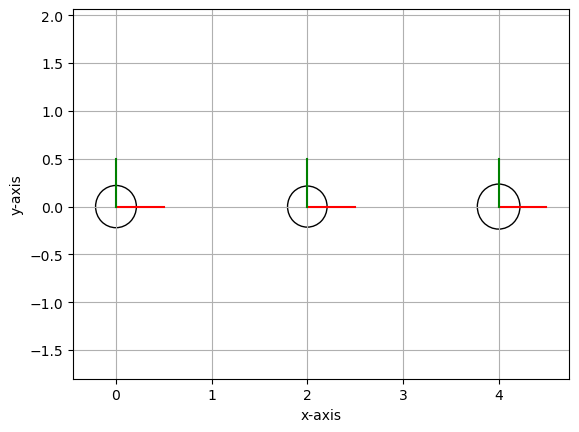

In [10]:
gtsam_plot.plot_pose2(0, result.atPose2(1), 0.5, marginals.marginalCovariance(1))
gtsam_plot.plot_pose2(0, result.atPose2(2), 0.5, marginals.marginalCovariance(2))
gtsam_plot.plot_pose2(0, result.atPose2(3), 0.5, marginals.marginalCovariance(3), ("x-axis", "y-axis", "theta-axis"))
plt.axis('equal')
plt.grid('on')
plt.show()


## 4 PoseSLAM

In [11]:
graph = gtsam.NonlinearFactorGraph()

priorNoise = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.3, 0.3, 0.1]))
graph.add(gtsam.PriorFactorPose2(1, gtsam.Pose2(0.0, 0.0, 0.0), priorNoise))

# Add odometry factors
model = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.2, 0.2, 0.1]))
graph.add(gtsam.BetweenFactorPose2(1, 2, gtsam.Pose2(2.0, 0.0, 0.0), model))
graph.add(gtsam.BetweenFactorPose2(2, 3, gtsam.Pose2(2.0, 0.0, np.pi/2), model))
graph.add(gtsam.BetweenFactorPose2(3, 4, gtsam.Pose2(2.0, 0.0, np.pi/2), model))
graph.add(gtsam.BetweenFactorPose2(4, 5, gtsam.Pose2(2.0, 0.0, np.pi/2), model))

# Add pose constraint
graph.add(gtsam.BetweenFactorPose2(5, 2, gtsam.Pose2(2.0, 0.0, np.pi/2), model))


In [12]:
initialEstimate = gtsam.Values()
initialEstimate.insert(1, gtsam.Pose2(0.1, 0.2, 0.15))
initialEstimate.insert(2, gtsam.Pose2(2.3, 0.1, -0.2))
initialEstimate.insert(3, gtsam.Pose2(4.1, -0.1, 0.1))
initialEstimate.insert(4, gtsam.Pose2(4.3, 1.6, 1.5))
initialEstimate.insert(5, gtsam.Pose2(2.5, 2.2, 2.9))

result = gtsam.LevenbergMarquardtOptimizer(graph, initialEstimate).optimize()
result.print()

Values with 5 values:
Value 1: (gtsam::Pose2)
(-4.04275228e-17, -5.2450694e-18, -6.74061164e-18)

Value 2: (gtsam::Pose2)
(2, -2.10573769e-17, -1.23156529e-17)

Value 3: (gtsam::Pose2)
(4, -9.65790365e-14, 1.57079633)

Value 4: (gtsam::Pose2)
(4, 2, -3.14159265)

Value 5: (gtsam::Pose2)
(2, 2, -1.57079633)



In [13]:
marginals = gtsam.Marginals(graph, result)
np.set_printoptions(precision=4, suppress=True)
#marginals.print("Marginals:\n")
print("x1 covariance:\n" + str(marginals.marginalCovariance(1)))
print("x2 covariance:\n" + str(marginals.marginalCovariance(2)))
print("x3 covariance:\n" + str(marginals.marginalCovariance(3)))
print("x4 covariance:\n" + str(marginals.marginalCovariance(4)))
print("x5 covariance:\n" + str(marginals.marginalCovariance(5)))


x1 covariance:
[[ 0.09 -0.    0.  ]
 [-0.    0.09 -0.  ]
 [ 0.   -0.    0.01]]
x2 covariance:
[[0.13 0.   0.  ]
 [0.   0.17 0.02]
 [0.   0.02 0.02]]
x3 covariance:
[[ 0.362  -0.      0.062 ]
 [-0.      0.162  -0.002 ]
 [ 0.062  -0.002   0.0265]]
x4 covariance:
[[ 0.268 -0.128  0.048]
 [-0.128  0.378 -0.068]
 [ 0.048 -0.068  0.028]]
x5 covariance:
[[ 0.202   0.036  -0.018 ]
 [ 0.036   0.26   -0.051 ]
 [-0.018  -0.051   0.0265]]


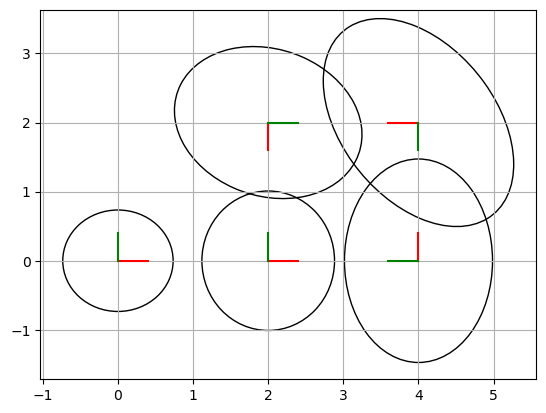

In [14]:
fig = plt.figure()
axes = fig.gca()

gtsam_plot.plot_pose2_on_axes(axes, result.atPose2(1), 0.4, marginals.marginalCovariance(1))
gtsam_plot.plot_pose2_on_axes(axes, result.atPose2(2), 0.4, marginals.marginalCovariance(2))
gtsam_plot.plot_pose2_on_axes(axes, result.atPose2(3), 0.4, marginals.marginalCovariance(3))
gtsam_plot.plot_pose2_on_axes(axes, result.atPose2(4), 0.4, marginals.marginalCovariance(4))
gtsam_plot.plot_pose2_on_axes(axes, result.atPose2(5), 0.4, marginals.marginalCovariance(5))
plt.grid('on')

## 4.3 Reading and Optimizing Pose Graphs

In [38]:
datafile = gtsam.findExampleDataFile('w100.graph')
model = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.05, 0.05, 5*np.pi/180]))

[graph, initial] = gtsam.load2D(datafile, model)

In [40]:
initial

Values with 100 values:
Value 0: (gtsam::Pose2)
(0.000000000, 0.000000000, 0.000000000)

Value 1: (gtsam::Pose2)
(0.995595000, 0.083720400, 0.014672800)

Value 2: (gtsam::Pose2)
(2.046300000, 0.035256300, -0.033261500)

Value 3: (gtsam::Pose2)
(3.011730000, 0.001176940, -0.015390400)

Value 4: (gtsam::Pose2)
(4.009730000, -0.079019400, -0.028750000)

Value 5: (gtsam::Pose2)
(5.019600000, -0.066491200, -0.039715000)

Value 6: (gtsam::Pose2)
(5.027440000, 0.934341000, 1.517680000)

Value 7: (gtsam::Pose2)
(5.047750000, 1.893230000, 1.510330000)

Value 8: (gtsam::Pose2)
(5.153060000, 2.874180000, 1.498660000)

Value 9: (gtsam::Pose2)
(5.223040000, 3.874970000, 1.483640000)

Value 10: (gtsam::Pose2)
(5.235960000, 4.870410000, 1.479510000)

Value 11: (gtsam::Pose2)
(4.245810000, 4.947960000, 2.999440000)

Value 12: (gtsam::Pose2)
(3.227580000, 5.095510000, 2.994920000)

Value 13: (gtsam::Pose2)
(2.191420000, 5.168870000, 2.987070000)

Value 14: (gtsam::Pose2)
(1.131100000, 5.243290000, 2.97

In [16]:
# Add a Gaussian prior on pose x_0
priorMean = gtsam.Pose2(0, 0, 0)
priorNoise = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.01, 0.01, 0.01]))
graph.add(gtsam.PriorFactorPose2(0, priorMean, priorNoise))

In [17]:
# Optimize using Levenberg-Marquardt optimization and get marginals
optimizer = gtsam.LevenbergMarquardtOptimizer(graph, initial)
result = optimizer.optimize()
marginals = gtsam.Marginals(graph, result)  

print("Graph error (initial):", graph.error(initial))
print("Graph error (result):", graph.error(result))

Graph error (initial): 15027.033279873533
Graph error (result): 213.3046076935409


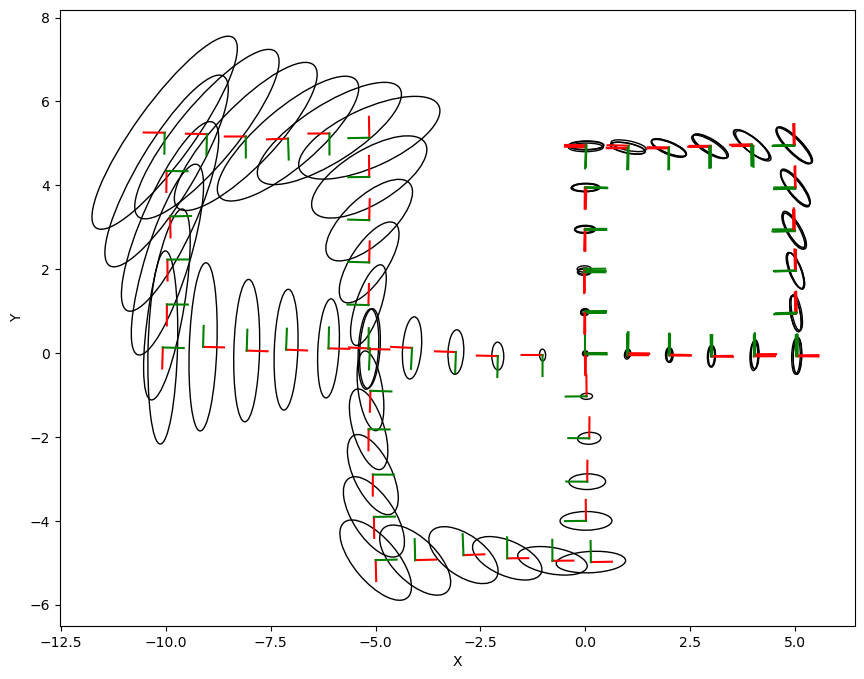

In [21]:
# Plot result
#gtsam_plot.plot_trajectory(fignum=1, values=initial, scale=0.5)

fig = plt.figure(1)
fig.set_size_inches(12, 8)
ax = fig.gca()  # 2D axes

poses2 = gtsam.utilities.allPose2s(result)
for k in poses2.keys():
    P = marginals.marginalCovariance(k)  # 3x3 Pose2 covariance
    gtsam_plot.plot_pose2_on_axes(ax, poses2.atPose2(k),
                                  axis_length=0.5, covariance=P)

ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('X'); ax.set_ylabel('Y')
plt.show()

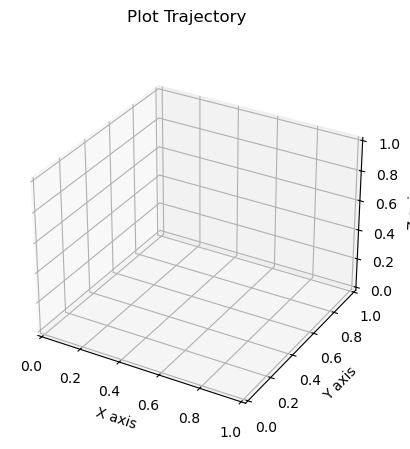

In [ ]:
datafile = gtsam.findExampleDataFile('sphere2500.txt')
model = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.05, 0.05, 0.1, 0.1, 0.1]))
[graph, initial] = gtsam.load3D(datafile) # initial is empty

# Plot initial estimate (requires a 3D plotting function, e.g., plot3DTrajectory)
gtsam_plot.plot_trajectory(fignum=1, values=initial, scale=0.5)

# Read again, now with all constraints, and optimize
# graph = gtsam.load3D(datafile, model)
# graph.add(gtsam.NonlinearEqualityPose3(0, initial.atPose3(0)))
# optimizer = gtsam.LevenbergMarquardtOptimizer(graph, initial)
# result = optimizer.optimizeSafely()

# Plot optimized result (requires a 3D plotting function)
# plot3DTrajectory(result, 'r-', False)
# plt.axis('equal')

## 5 Landmark-based SLAM

AttributeError: module 'gtsam' has no attribute 'visualSLAMGraph'

# Grid

Optimized values:
Node (0, 0): [3.74116893e-11 2.31993507e-12]
Node (0, 1): [-0.00249941  0.99999688]
Node (0, 2): [0.03525188 1.99928404]
Node (1, 0): [0.99874199 0.05014425]
Node (1, 1): [0.99624258 1.05014114]
Node (1, 2): [1.03399386 2.04942831]
Node (2, 0): [ 1.99651924 -0.01649323]
Node (2, 1): [1.99401983 0.98350367]
Node (2, 2): [2.03177112 1.98279084]


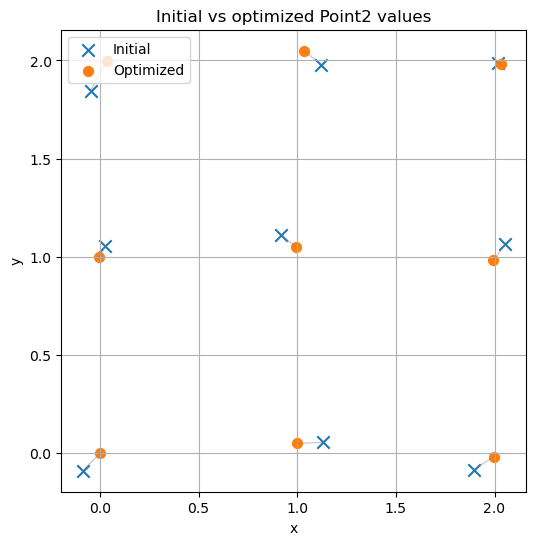

In [22]:

fg = gtsam.NonlinearFactorGraph()
init_values = gtsam.Values()

N = 3

def node_key(i, j):
    return X(i*N+j)

for i in range(N):
    for j in range(N):
        gt = gtsam.Point2(i, j)
        z = gt + np.random.normal(0, 0.1, size=2)
        init_values.insert(node_key(i, j), z)
        
for i in range(N):
    for j in range(N-1):
        factor1 = gtsam.RangeFactor2(
            node_key(i, j), 
            node_key(i, j+1), 
            1.0, 
            gtsam.noiseModel.Isotropic.Sigma(1, 0.1)
        )
        factor2 = gtsam.RangeFactor2(
            node_key(j, i), 
            node_key(j+1, i), 
            1.0, 
            gtsam.noiseModel.Isotropic.Sigma(1, 0.1)
        )
        
        fg.add(factor1)
        fg.add(factor2)

fg.add(gtsam.PriorFactorPoint2(node_key(0, 0), gtsam.Point2(0, 0), gtsam.noiseModel.Isotropic.Sigma(2, 0.1)))

optimizer = gtsam.LevenbergMarquardtOptimizer(fg, init_values)
result = optimizer.optimize()
print("Optimized values:")
for i in range(N):
    for j in range(N):
        print(f"Node ({i}, {j}): {result.atPoint2(node_key(i, j))}")    

initial_xy = []
optimized_xy = []
for i in range(N):
    for j in range(N):
        key = node_key(i, j)
        initial_xy.append(init_values.atPoint2(key))
        optimized_xy.append(result.atPoint2(key))

initial_xy = np.array(initial_xy)
optimized_xy = np.array(optimized_xy)

plt.figure(figsize=(6, 6))
plt.scatter(initial_xy[:, 0], initial_xy[:, 1], label="Initial", marker="x", s=80)
plt.scatter(optimized_xy[:, 0], optimized_xy[:, 1], label="Optimized", marker="o", s=50)

for start, end in zip(initial_xy, optimized_xy):
    plt.plot([start[0], end[0]], [start[1], end[1]], color="gray", alpha=0.4, linewidth=1)

plt.axis("equal")
plt.grid(True)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Initial vs optimized Point2 values")
plt.show()


Optimized values with relative position factors:
Node (0, 0): [ 2.74512127e-14 -2.18432567e-14]
Node (0, 1): [4.01436908e-14 1.00000000e+00]
Node (0, 2): [4.52946497e-14 2.00000000e+00]
Node (1, 0): [ 1.00000000e+00 -3.18429136e-14]
Node (1, 1): [1. 1.]
Node (1, 2): [1. 2.]
Node (2, 0): [ 2.00000000e+00 -3.59762177e-14]
Node (2, 1): [2. 1.]
Node (2, 2): [2. 2.]


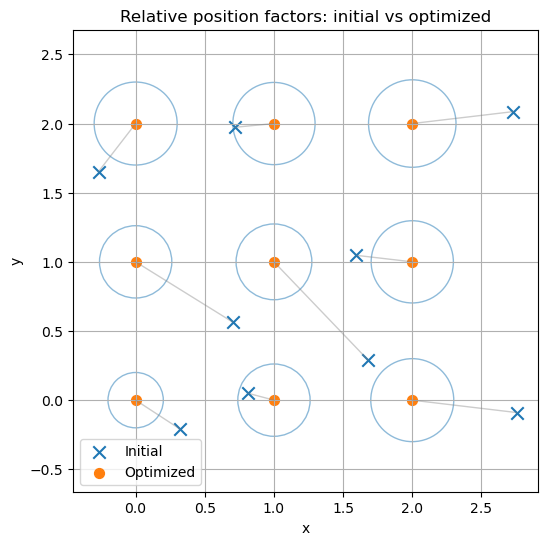

In [ ]:
# Same grid example, but with relative position measurements (dx, dy)
fg_relative = gtsam.NonlinearFactorGraph()
init_relative = gtsam.Values()

N = 3

def node_key(i, j):
    return X(i*N+j)

for i in range(N):
    for j in range(N):
        gt = gtsam.Point2(i, j)
        z = gt + np.random.normal(0, 0.5, size=2)
        init_relative.insert(node_key(i, j), z)

relative_noise = gtsam.noiseModel.Isotropic.Sigma(2, 0.1)

for i in range(N):
    for j in range(N - 1):
        fg_relative.add(gtsam.BetweenFactorPoint2(
            node_key(i, j),
            node_key(i, j + 1),
            gtsam.Point2(0.0, 1.0),
            relative_noise,
        ))
        fg_relative.add(gtsam.BetweenFactorPoint2(
            node_key(j, i),
            node_key(j + 1, i),
            gtsam.Point2(1.0, 0.0),
            relative_noise,
        ))

fg_relative.add(gtsam.PriorFactorPoint2(
    node_key(0, 0),
    gtsam.Point2(0, 0),
    gtsam.noiseModel.Isotropic.Sigma(2, 0.1),
))

optimizer = gtsam.LevenbergMarquardtOptimizer(fg_relative, init_relative)
result_relative = optimizer.optimize()
marginals_relative = gtsam.Marginals(fg_relative, result_relative)

print("Optimized values with relative position factors:")
for i in range(N):
    for j in range(N):
        print(f"Node ({i}, {j}): {result_relative.atPoint2(node_key(i, j))}")

from matplotlib.patches import Ellipse

def covariance_ellipse(mean, covariance, n_std=2.0, **kwargs):
    eigvals, eigvecs = np.linalg.eigh(covariance)
    order = eigvals.argsort()[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    width, height = 2 * n_std * np.sqrt(eigvals)
    return Ellipse(xy=mean, width=width, height=height, angle=angle, **kwargs)

initial_xy = []
optimized_xy = []
optimized_covariances = []
for i in range(N):
    for j in range(N):
        key = node_key(i, j)
        initial_xy.append(init_relative.atPoint2(key))
        optimized_xy.append(result_relative.atPoint2(key))
        optimized_covariances.append(marginals_relative.marginalCovariance(key))

initial_xy = np.array(initial_xy)
optimized_xy = np.array(optimized_xy)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(initial_xy[:, 0], initial_xy[:, 1], label="Initial", marker="x", s=80)
ax.scatter(optimized_xy[:, 0], optimized_xy[:, 1], label="Optimized", marker="o", s=50)

for start, end in zip(initial_xy, optimized_xy):
    ax.plot([start[0], end[0]], [start[1], end[1]], color="gray", alpha=0.4, linewidth=1)

for mean, covariance in zip(optimized_xy, optimized_covariances):
    ax.add_patch(covariance_ellipse(mean, covariance, edgecolor="tab:blue", facecolor="none", alpha=0.5))

ax.axis("equal")
ax.grid(True)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
ax.set_title("Relative position factors: initial vs optimized")
plt.show()


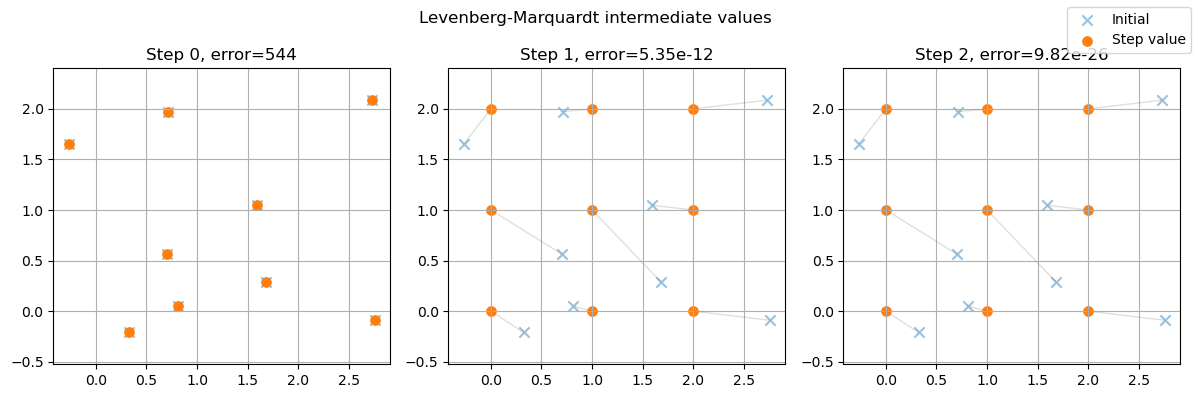

In [25]:
# Plot each optimizer step for the relative-position graph.
step_optimizer = gtsam.LevenbergMarquardtOptimizer(fg_relative, init_relative)
step_values = [init_relative]
step_errors = [fg_relative.error(init_relative)]

max_steps = 10
error_tol = 1e-9

for _ in range(max_steps):
    previous_error = step_optimizer.error()
    step_optimizer.iterate()
    current_values = step_optimizer.values()
    current_error = fg_relative.error(current_values)
    step_values.append(current_values)
    step_errors.append(current_error)

    if abs(previous_error - current_error) < error_tol:
        break

cols = min(4, len(step_values))
rows = int(np.ceil(len(step_values) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows), squeeze=False)

for step_idx, values in enumerate(step_values):
    ax = axes[step_idx // cols, step_idx % cols]
    xy = np.array([
        values.atPoint2(node_key(i, j))
        for i in range(N)
        for j in range(N)
    ])

    ax.scatter(initial_xy[:, 0], initial_xy[:, 1], label="Initial", marker="x", s=55, alpha=0.45)
    ax.scatter(xy[:, 0], xy[:, 1], label="Step value", marker="o", s=45)

    previous_xy = initial_xy if step_idx == 0 else np.array([
        step_values[step_idx - 1].atPoint2(node_key(i, j))
        for i in range(N)
        for j in range(N)
    ])

    for start, end in zip(previous_xy, xy):
        ax.plot([start[0], end[0]], [start[1], end[1]], color="gray", alpha=0.25, linewidth=1)

    ax.axis("equal")
    ax.grid(True)
    ax.set_title(f"Step {step_idx}, error={step_errors[step_idx]:.3g}")

for ax in axes.flat[len(step_values):]:
    ax.axis("off")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Levenberg-Marquardt intermediate values")
fig.tight_layout()
plt.show()


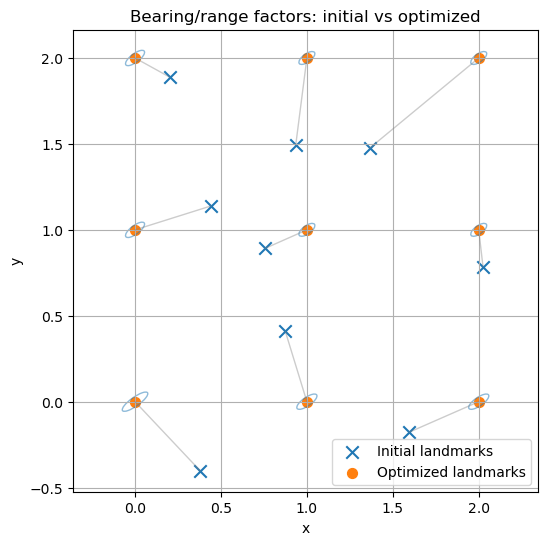

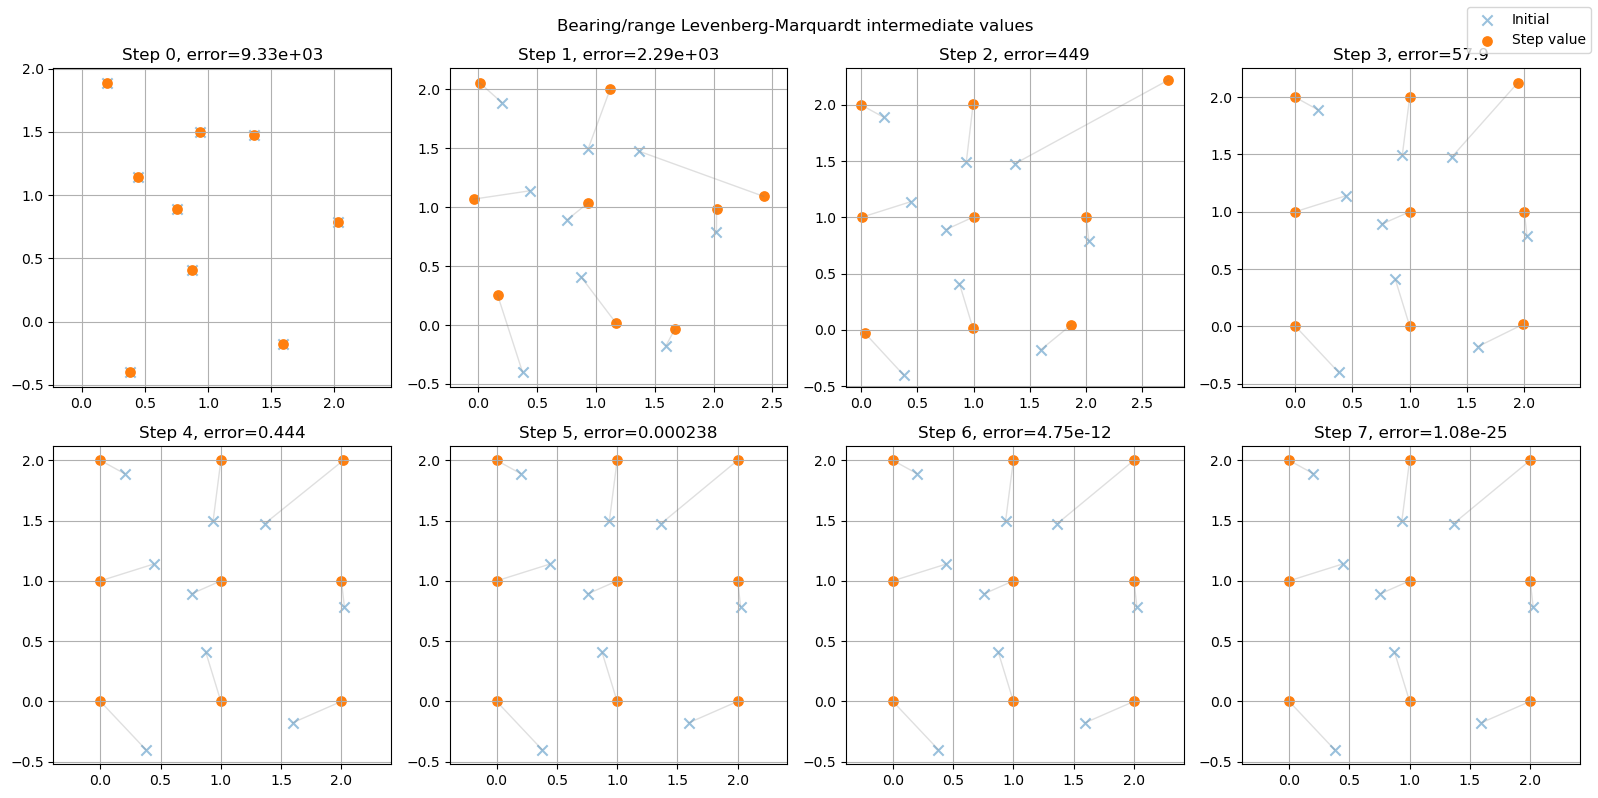

In [26]:
# Nonlinear grid example with bearing/range measurements.
import gtsam
import matplotlib.pyplot as plt
import numpy as np
from gtsam.symbol_shorthand import L, X
from matplotlib.patches import Ellipse

fg_br = gtsam.NonlinearFactorGraph()
init_br = gtsam.Values()

N = 3

def node_idx(i, j):
    return i * N + j

def point_key(i, j):
    return L(node_idx(i, j))

def pose_key(i, j):
    return X(node_idx(i, j))

def covariance_ellipse(mean, covariance, n_std=2.0, **kwargs):
    eigvals, eigvecs = np.linalg.eigh(covariance)
    order = eigvals.argsort()[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    width, height = 2 * n_std * np.sqrt(eigvals)
    return Ellipse(xy=mean, width=width, height=height, angle=angle, **kwargs)

pose_noise = gtsam.noiseModel.Diagonal.Sigmas(np.array([1e-3, 1e-3, 1e-3]))
bearing_range_noise = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.03, 0.05]))
landmark_prior_noise = gtsam.noiseModel.Isotropic.Sigma(2, 0.1)

gt_poses = {}
gt_points = {}

for i in range(N):
    for j in range(N):
        idx = node_idx(i, j)
        gt_pose = gtsam.Pose2(i - 0.35, j - 0.25, 0.15)
        gt_point = gtsam.Point2(i, j)
        gt_poses[idx] = gt_pose
        gt_points[idx] = gt_point

        init_br.insert(pose_key(i, j), gt_pose)
        init_br.insert(point_key(i, j), gt_point + np.random.normal(0, 0.35, size=2))
        fg_br.add(gtsam.PriorFactorPose2(pose_key(i, j), gt_pose, pose_noise))

fg_br.add(gtsam.PriorFactorPoint2(point_key(0, 0), gtsam.Point2(0, 0), landmark_prior_noise))

for i in range(N):
    for j in range(N):
        source_pose = gt_poses[node_idx(i, j)]
        for ni, nj in [(i, j), (i + 1, j), (i, j + 1)]:
            if ni >= N or nj >= N:
                continue

            target_point = gt_points[node_idx(ni, nj)]
            measured_bearing = gtsam.BearingRange2D.MeasureBearing(source_pose, target_point)
            measured_range = gtsam.BearingRange2D.MeasureRange(source_pose, target_point)
            fg_br.add(gtsam.BearingRangeFactor2D(
                pose_key(i, j),
                point_key(ni, nj),
                measured_bearing,
                measured_range,
                bearing_range_noise,
            ))

optimizer_br = gtsam.LevenbergMarquardtOptimizer(fg_br, init_br)
result_br = optimizer_br.optimize()
marginals_br = gtsam.Marginals(fg_br, result_br)

initial_xy = []
optimized_xy = []
optimized_covariances = []
for i in range(N):
    for j in range(N):
        key = point_key(i, j)
        initial_xy.append(init_br.atPoint2(key))
        optimized_xy.append(result_br.atPoint2(key))
        optimized_covariances.append(marginals_br.marginalCovariance(key))

initial_xy = np.array(initial_xy)
optimized_xy = np.array(optimized_xy)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(initial_xy[:, 0], initial_xy[:, 1], label="Initial landmarks", marker="x", s=80)
ax.scatter(optimized_xy[:, 0], optimized_xy[:, 1], label="Optimized landmarks", marker="o", s=50)

for start, end in zip(initial_xy, optimized_xy):
    ax.plot([start[0], end[0]], [start[1], end[1]], color="gray", alpha=0.4, linewidth=1)

for mean, covariance in zip(optimized_xy, optimized_covariances):
    ax.add_patch(covariance_ellipse(mean, covariance, edgecolor="tab:blue", facecolor="none", alpha=0.5))

ax.axis("equal")
ax.grid(True)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
ax.set_title("Bearing/range factors: initial vs optimized")
plt.show()

step_optimizer_br = gtsam.LevenbergMarquardtOptimizer(fg_br, init_br)
step_values_br = [init_br]
step_errors_br = [fg_br.error(init_br)]

max_steps = 10
error_tol = 1e-9

for _ in range(max_steps):
    previous_error = step_optimizer_br.error()
    step_optimizer_br.iterate()
    current_values = step_optimizer_br.values()
    current_error = fg_br.error(current_values)
    step_values_br.append(current_values)
    step_errors_br.append(current_error)

    if abs(previous_error - current_error) < error_tol:
        break

cols = min(4, len(step_values_br))
rows = int(np.ceil(len(step_values_br) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows), squeeze=False)

for step_idx, values in enumerate(step_values_br):
    ax = axes[step_idx // cols, step_idx % cols]
    xy = np.array([
        values.atPoint2(point_key(i, j))
        for i in range(N)
        for j in range(N)
    ])

    ax.scatter(initial_xy[:, 0], initial_xy[:, 1], label="Initial", marker="x", s=55, alpha=0.45)
    ax.scatter(xy[:, 0], xy[:, 1], label="Step value", marker="o", s=45)

    previous_xy = initial_xy if step_idx == 0 else np.array([
        step_values_br[step_idx - 1].atPoint2(point_key(i, j))
        for i in range(N)
        for j in range(N)
    ])

    for start, end in zip(previous_xy, xy):
        ax.plot([start[0], end[0]], [start[1], end[1]], color="gray", alpha=0.25, linewidth=1)

    ax.axis("equal")
    ax.grid(True)
    ax.set_title(f"Step {step_idx}, error={step_errors_br[step_idx]:.3g}")

for ax in axes.flat[len(step_values_br):]:
    ax.axis("off")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Bearing/range Levenberg-Marquardt intermediate values")
fig.tight_layout()
plt.show()
